## Import

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import re
import matplotlib.image as mpimg
import os
from glob import glob
from PIL import Image
from itertools import product

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

from functools import partial

# Полностью отключить все предупреждения
warnings.filterwarnings("ignore")

os.makedirs("ims", exist_ok=True)
# os.makedirs("ims/current", exist_ok=True)
os.makedirs("ims/all", exist_ok=True)

plt.rcParams['font.family'] = 'serif'
import matplotlib
# matplotlib.use('Agg')
# print(matplotlib.get_backend())

## extract

In [7]:
def extract_first_symbol(s):
    return int(s[0])

def extract_c_num(s):
    start = s.index('c') + 1
    end = s.index('_', start)
    return int(s[start:end])

def extract_s_num(s):
    start = s.index('_s') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_k_num(s):
    start = s.index('_k') + 2
    end = s.index('_', start)
    return int(s[start:end])

def extract_a_num(s):
    start = s.index('_a') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_r_num(s):
    start = s.index('_r') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_i_num(s):
    start = s.index('_i') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_p(s):
    match = re.search(r'p([^_]+)', s)
    s1 = match.group(1).split('d')[0]
    s2 = match.group(1).split('d')[1]
    return float(s2+s1)
        # return match.group(1)[-2:]+match.group(1)[:-2]

In [8]:
ax = 'z'

folders = [name for name in os.listdir('.') if os.path.isdir(os.path.join('.', name))]

# folders = [f for f in folders if f.startswith('c')]
# folders = [f for f in folders 
#            if f[0].isdigit() 
#            and os.path.isfile(os.path.join(f, 'probe_pulse_rt.data')) 
#            and not os.path.isdir(os.path.join(f, 'restart'))]


folders = [f for f in folders 
           if os.path.isfile(os.path.join(f, 'both_pulses_rt.data')) 
           and not os.path.isdir(os.path.join(f, 'restart'))]

# print(folders)


# Сортировка: сначала по c, потом по s, потом по k
sorted_folders = sorted(folders, key=lambda s: (extract_p(s), extract_c_num(s), extract_r_num(s), extract_s_num(s), extract_k_num(s), extract_a_num(s), extract_i_num(s)))

# sorted_folders = sorted(folders, key=lambda s: extract_first_symbol(s))

In [10]:
sorted_folders

['c111_s0.05_r16_k16_a1_i800_t9_p1.4d10_5d11',
 'c211_s0.05_r16_k16_a1_i800_t9_p1.4d10_5d11',
 'c222_s0.05_r16_k16_a1_i800_t9_p1.4d10_5d11',
 'c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12']

## dos hist

In [53]:
def get_numk_numstates(folder):

    gs_file = glob(folder + "/Si_gs*.inp")[0]
    gs_file
    
    kprod = None
    nstate = None
    
    with open(gs_file) as f:
        for line in f:
            line = line.strip()
    
            if "num_kgrid" in line:
                # num_kgrid(1:3) = 8, 16, 16
                nums = line.split("=")[1].split(",")
                kx, ky, kz = map(int, nums)
                kprod = kx * ky * kz
    
            if "nstate" in line:
                # nstate = 64
                nstate = int(line.split("=")[1])
    
    # print("k-point product:", kprod)
    # print("nstate:", nstate)

    return (kprod, nstate)

In [54]:
get_numk_numstates(sorted_folders[3])

(125, 864)

In [13]:
def read_energies_for_k(filename, k_target, n_levels=864):
    """
    Возвращает массив энергий (eV) длины n_levels для заданного k
    """
    energies = []
    reading = False

    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()

            # начало блока
            if line.startswith('k='):
                k_current = int(line.split(',')[0].split('=')[1])
                reading = (k_current == k_target)
                continue

            # читаем строки с энергиями
            if reading:
                if len(energies) < n_levels:
                    parts = line.split()
                    energy = float(parts[1])  # столбец esp[eV]
                    energies.append(energy)
                else:
                    break

    if len(energies) != n_levels:
        raise ValueError(f'Для k={k_target} найдено {len(energies)} уровней, ожидалось {n_levels}')

    return np.array(energies)

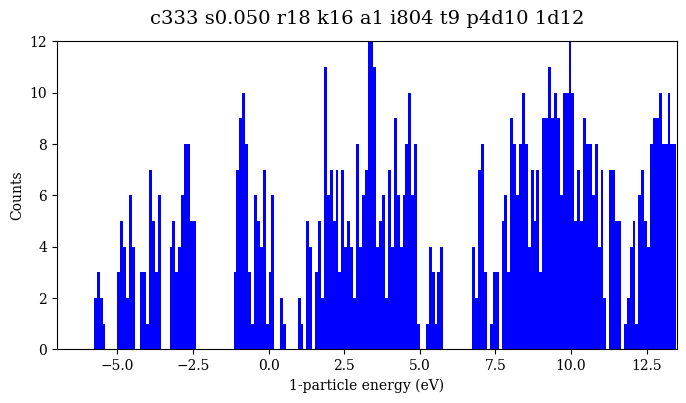

In [14]:
folder = sorted_folders[3]
filename = folder + '/gs_eigen.data'

bins_num = 200


for k_val in range(125):

    energies = read_energies_for_k(filename, k_val+1)


    if (k_val+1)==125:
    
        plt.figure(figsize=(8, 4))
        plt.title(' '.join(re.split('[/_]', folder)), fontsize=14, y=1.03)
        plt.hist(energies, bins=bins_num, color='b')  # bins можешь менять
        plt.xlabel("1-particle energy (eV)")
        plt.ylabel("Counts")
        plt.ylim(0, 12)
        plt.xlim(-7, 13.5)